# Task 4: Análisis ACF vs atención y comparación LSTM vs Transformer

## 1. Preparación de datos (Task 1)

In [1]:
import ssl
import time
import urllib.error
import urllib.request
from pathlib import Path

import certifi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
torch.set_num_threads(max(1, torch.get_num_threads()))
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cpu


In [2]:
URL = (
    'https://raw.githubusercontent.com/zhouhaoyi/'
    'ETDataset/main/ETT-small/ETTh1.csv'
)
DATA_PATH = Path('ETTh1.csv')

if not DATA_PATH.exists():
    try:
        urllib.request.urlretrieve(URL, DATA_PATH)
    except urllib.error.URLError as error:
        if DATA_PATH.exists():
            DATA_PATH.unlink()
        ssl_context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(URL, context=ssl_context) as response:
            DATA_PATH.write_bytes(response.read())
        print(f'La descarga estándar falló ({error.reason}); se usó certifi.')

data = np.genfromtxt(DATA_PATH, delimiter=',', skip_header=1)
OT = data[:, -1].astype(np.float32)
OT_tensor = torch.from_numpy(OT)
mu = OT_tensor.mean()
sigma = OT_tensor.std(correction=0)
OT_norm = (OT_tensor - mu) / sigma

T = OT_norm.numel()
train_end = int(0.60 * T)
val_end = int(0.80 * T)
OT_train = OT_norm[:train_end].clone()
OT_val = OT_norm[train_end:val_end].clone()
OT_test = OT_norm[val_end:].clone()


def make_windows(series: torch.Tensor, L: int, H: int):
    # X(t) = (x_{t-L+1}, ..., x_t),  y(t) = x_{t+H}
    windows = series.unfold(0, L + H, 1)
    return windows[:, :L].contiguous(), windows[:, -1].contiguous()


L = 96
HORIZONS = (24, 48)
windows = {
    H: {
        'train': make_windows(OT_train, L, H),
        'val': make_windows(OT_val, L, H),
    }
    for H in HORIZONS
}
print(f'Train={OT_train.shape}, val={OT_val.shape}, test={OT_test.shape}')

Train=torch.Size([10452]), val=torch.Size([3484]), test=torch.Size([3484])


## 2. ACF manual (Task 1.2)

In [3]:
def acf_manual(series, max_lag):
    # rho(k) = [1/(N-k) * sum_{t=k}^{N-1} (x_t - x̄)(x_{t-k} - x̄)] / [1/N * sum_t (x_t - x̄)^2]
    x = torch.as_tensor(series, dtype=torch.float32)
    N = x.numel()
    centered = x - x.mean()
    denominator = centered.square().mean()
    return torch.stack([
        (centered[k:] * centered[:N - k]).mean() / denominator
        for k in range(max_lag + 1)
    ])


def pacf_durbin_levinson(rho, max_lag):
    # Autocorrelación parcial a partir de la ACF (recursión de Durbin-Levinson).
    rho = rho.double()
    pacf = torch.zeros(max_lag + 1, dtype=torch.float64)
    pacf[0] = 1.0
    phi_prev = torch.zeros(0, dtype=torch.float64)
    for k in range(1, max_lag + 1):
        if k == 1:
            phi_kk = rho[1]
            phi = phi_kk.reshape(1)
        else:
            num = rho[k] - (phi_prev * rho[1:k].flip(0)).sum()
            den = 1.0 - (phi_prev * rho[1:k]).sum()
            phi_kk = num / den
            phi = torch.cat((phi_prev - phi_kk * phi_prev.flip(0), phi_kk.reshape(1)))
        pacf[k] = phi_kk
        phi_prev = phi
    return pacf.float()


acf_values = acf_manual(OT_train, L)
pacf_values = pacf_durbin_levinson(acf_values, L)
confidence = 1.96 / OT_train.numel() ** 0.5
print(f'ACF(1)={acf_values[1]:.4f}, ACF(22)={acf_values[22]:.4f}, ACF(24)={acf_values[24]:.4f}, '
      f'ACF(48)={acf_values[48]:.4f}, ACF(96)={acf_values[96]:.4f}')
print(f'IC 95%: ±{confidence:.4f}')

ACF(1)=0.9923, ACF(22)=0.9262, ACF(24)=0.9250, ACF(48)=0.8763, ACF(96)=0.8489
IC 95%: ±0.0192


## 3. Modelos (Tasks 2.1, 3.1 y 3.2)

In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in))
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h))
        self.b = nn.Parameter(torch.zeros(4 * d_h))
        self.W_out = nn.Parameter(torch.empty(1, d_h))
        self.b_out = nn.Parameter(torch.zeros(1))

        for Wx_gate in self.Wx.chunk(4, dim=0):
            nn.init.xavier_uniform_(Wx_gate)
        for Wh_gate in self.Wh.chunk(4, dim=0):
            nn.init.orthogonal_(Wh_gate)
        nn.init.xavier_uniform_(self.W_out)
        with torch.no_grad():
            self.b[d_h:2 * d_h].fill_(1.0)

    def forward(self, x):
        x = x.reshape(x.shape[0], x.shape[1], 1)
        B, L, _ = x.shape
        h = x.new_zeros(B, self.d_h)
        c = x.new_zeros(B, self.d_h)
        for t in range(L):
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b
            i, f, g, o = gates.chunk(4, dim=-1)
            i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
            g = torch.tanh(g)
            c = f * c + i * g            # c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t
            h = o * torch.tanh(c)        # h_t = o_t ⊙ tanh(c_t)
        return (h @ self.W_out.T + self.b_out).squeeze(-1)


def make_pe(max_len, d_model):
    t = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
    two_i = torch.arange(0, d_model, 2, dtype=torch.float32)
    angles = t / torch.pow(10000.0, two_i / d_model)
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles[:, :d_model // 2])
    return pe


class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.L = L

        self.input_proj = nn.Linear(1, d_model)
        self.register_buffer('PE', make_pe(L, d_model))
        self.WQ = nn.Parameter(torch.empty(d_model, d_model))
        self.WK = nn.Parameter(torch.empty(d_model, d_model))
        self.WV = nn.Parameter(torch.empty(d_model, d_model))
        self.WO = nn.Parameter(torch.empty(d_model, d_model))
        self.W1 = nn.Parameter(torch.empty(d_model, d_ff))
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.empty(d_ff, d_model))
        self.b2 = nn.Parameter(torch.zeros(d_model))
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))
        self.W_out = nn.Linear(d_model, 1)
        for W in (self.WQ, self.WK, self.WV, self.WO, self.W1, self.W2):
            nn.init.xavier_uniform_(W)

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return gamma * (x - mean) / torch.sqrt(var + eps) + beta

    def multi_head_attention(self, x):
        B, L, _ = x.shape
        Q = (x @ self.WQ).reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)
        K = (x @ self.WK).reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)
        V = (x @ self.WV).reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)
        scores = Q @ K.transpose(-2, -1) / self.d_k ** 0.5   # e_ts = q_t^T k_s / sqrt(d_k)
        attn_w = torch.softmax(scores, dim=-1)
        out = (attn_w @ V).transpose(1, 2).reshape(B, L, self.d_model)
        return out @ self.WO, attn_w

    def feed_forward(self, x):
        return torch.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, return_attn=False):
        L = x.shape[1]
        x = self.input_proj(x.unsqueeze(-1)) + self.PE[:L]
        att_out, attn_w = self.multi_head_attention(x)
        x = self.layer_norm(x + att_out, self.gamma1, self.beta1)
        x = self.layer_norm(x + self.feed_forward(x), self.gamma2, self.beta2)
        pred = self.W_out(x[:, 0, :]).squeeze(-1)
        return (pred, attn_w) if return_attn else pred

## 4. Entrenamiento con las condiciones de las Tasks 2.2 y 3.3

In [5]:
MODEL_FACTORIES = {
    'LSTM': lambda: LSTMForecaster(d_in=1, d_h=32),
    'Transformer': lambda: TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96),
}
SEEDS = {24: 42, 48: 90}


def predict_batched(model, X, batch_size=256):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(X[s:s + batch_size]) for s in range(0, X.shape[0], batch_size)])


def train_model(name, X, y, X_val, y_val, epochs=20, batch_size=64, lr=5e-3, seed=42):
    torch.manual_seed(seed)
    model = MODEL_FACTORIES[name]()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    N = X.shape[0]
    best_val_mae, best_state, history = float('inf'), None, []

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(N)
        total_loss = 0.0
        for start in range(0, N, batch_size):
            idx = permutation[start:start + batch_size]
            optimizer.zero_grad(set_to_none=True)
            loss = F.l1_loss(model(X[idx]), y[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item() * idx.numel()

        val_mae = torch.abs(y_val - predict_batched(model, X_val)).mean().item()
        history.append((total_loss / N, val_mae))
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, history


models, histories = {}, {}
for name in MODEL_FACTORIES:
    for H in HORIZONS:
        start = time.perf_counter()
        X_tr, y_tr = windows[H]['train']
        X_vl, y_vl = windows[H]['val']
        models[name, H], histories[name, H] = train_model(name, X_tr, y_tr, X_vl, y_vl, seed=SEEDS[H])
        best = min(v for _, v in histories[name, H])
        print(f'{name:<12} H={H}: mejor MAE val={best:.4f} ({time.perf_counter() - start:.0f} s)')

LSTM         H=24: mejor MAE val=0.2389 (211 s)
LSTM         H=48: mejor MAE val=0.3226 (208 s)
Transformer  H=24: mejor MAE val=0.2326 (111 s)
Transformer  H=48: mejor MAE val=0.2620 (111 s)


# Task 4.1: ACF vs mapa de atención

## 1. Atención desde la posición CLS por lag

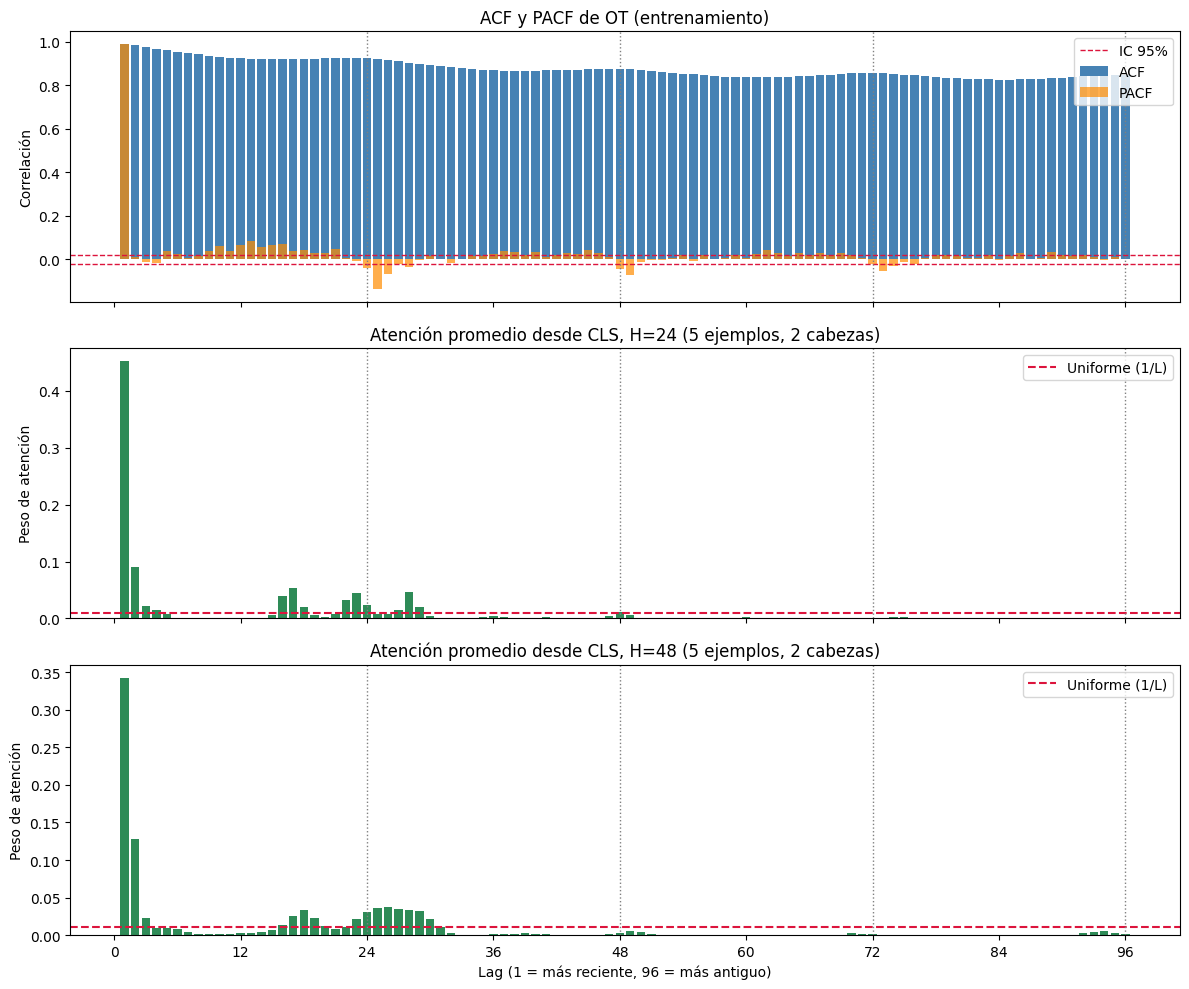

In [6]:
positions = torch.arange(L)
lag_of_position = L - positions
lag_axis = torch.arange(1, L + 1)


def attention_indices(X, n_examples=5):
    return torch.linspace(0, X.shape[0] - 1, n_examples).long()


def cls_attention_by_lag(model, X):
    # Devuelve atención CLS por lag: (n_ejemplos, n_heads, L), índice k-1 = lag k
    model.eval()
    with torch.no_grad():
        _, attn_w = model(X, return_attn=True)
    return attn_w[:, :, 0, :].flip(-1)


cls_attn = {}
for H in HORIZONS:
    X_vl, _ = windows[H]['val']
    cls_attn[H] = cls_attention_by_lag(models['Transformer', H], X_vl[attention_indices(X_vl)])

attn_mean_by_lag = {H: cls_attn[H].mean(dim=(0, 1)) for H in HORIZONS}
acf_by_lag = acf_values[1:]
pacf_by_lag = pacf_values[1:]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].bar(lag_axis, acf_by_lag, color='steelblue', label='ACF')
axes[0].bar(lag_axis, pacf_by_lag, color='darkorange', alpha=0.7, label='PACF')
axes[0].axhline(confidence, color='crimson', linestyle='--', linewidth=1)
axes[0].axhline(-confidence, color='crimson', linestyle='--', linewidth=1, label='IC 95%')
axes[0].set_ylabel('Correlación')
axes[0].set_title('ACF y PACF de OT (entrenamiento)')
axes[0].legend()
for ax, H in zip(axes[1:], HORIZONS):
    ax.bar(lag_axis, attn_mean_by_lag[H], color='seagreen')
    ax.axhline(1 / L, color='crimson', linestyle='--', label='Uniforme (1/L)')
    ax.set_ylabel('Peso de atención')
    ax.set_title(f'Atención promedio desde CLS, H={H} (5 ejemplos, 2 cabezas)')
    ax.legend()
for ax in axes:
    for daily in (24, 48, 72, 96):
        ax.axvline(daily, color='gray', linestyle=':', linewidth=1)
axes[-1].set_xlabel('Lag (1 = más reciente, 96 = más antiguo)')
axes[-1].set_xticks(range(0, L + 1, 12))
plt.tight_layout()
plt.show()

## 2. Comparación numérica

In [7]:
pd.set_option('display.precision', 4)

def top_lags(values, k=10):
    top = torch.topk(values, k)
    return (top.indices + 1).tolist(), top.values.tolist()

acf_top_lags, acf_top_vals = top_lags(acf_by_lag)
local_peak = (acf_values[1:-1] > acf_values[:-2]) & (acf_values[1:-1] > acf_values[2:])
acf_peak_lags = (torch.arange(1, L)[local_peak]).tolist()

rows = []
for rank in range(10):
    row = {'rank': rank + 1,
           'ACF lag': acf_top_lags[rank], 'ACF': acf_top_vals[rank]}
    for H in HORIZONS:
        lags_H, vals_H = top_lags(attn_mean_by_lag[H])
        row[f'Atn H={H} lag'] = lags_H[rank]
        row[f'Atn H={H}'] = vals_H[rank]
    rows.append(row)
top_table = pd.DataFrame(rows).set_index('rank')
print('Top 10 lags según ACF y según atención desde CLS')
display(top_table)

print(f'Picos locales de la ACF (lags): {acf_peak_lags}')
print('ACF y PACF en los picos locales:')
display(pd.DataFrame({
    'lag': acf_peak_lags,
    'ACF': [acf_values[k].item() for k in acf_peak_lags],
    'PACF': [pacf_values[k].item() for k in acf_peak_lags],
    'Atn H=24': [attn_mean_by_lag[24][k - 1].item() for k in acf_peak_lags],
    'Atn H=48': [attn_mean_by_lag[48][k - 1].item() for k in acf_peak_lags],
}).set_index('lag'))

Top 10 lags según ACF y según atención desde CLS


,ACF lag,ACF,Atn H=24 lag,Atn H=24,Atn H=48 lag,Atn H=48
rank,,,,,,
1,1,0.9923,1,0.4522,1,0.3426
2,2,0.9849,2,0.0902,2,0.1281
3,3,0.9773,17,0.0539,26,0.0373
4,4,0.9696,28,0.0468,25,0.0367
5,5,0.9625,23,0.0442,27,0.0344
6,6,0.9558,16,0.0402,18,0.0337
7,7,0.9492,22,0.0317,28,0.0336
8,8,0.9429,24,0.0243,29,0.0319
9,9,0.9372,3,0.0218,24,0.0314


Picos locales de la ACF (lags): [22, 47, 72]
ACF y PACF en los picos locales:


,ACF,PACF,Atn H=24,Atn H=48
lag,,,,
22,0.9262,0.0071,0.0317,0.0107
47,0.8770,0.0088,0.0041,0.0013
72,0.8572,-0.0232,0.0006,0.0010


In [8]:
selected_lags = [1, 2, 3, 6, 12, 18, 20, 22, 24, 26, 36, 47, 48, 60, 72, 84, 96]
by_lag = pd.DataFrame({
    'ACF': [acf_values[k].item() for k in selected_lags],
    'PACF': [pacf_values[k].item() for k in selected_lags],
    'Atn H=24': [attn_mean_by_lag[24][k - 1].item() for k in selected_lags],
    'Atn H=48': [attn_mean_by_lag[48][k - 1].item() for k in selected_lags],
}, index=pd.Index(selected_lags, name='lag'))
display(by_lag)


def spearman(a, b):
    ra = a.argsort().argsort().float()
    rb = b.argsort().argsort().float()
    return torch.corrcoef(torch.stack((ra, rb)))[0, 1].item()


blocks = {'1-24': slice(0, 24), '25-48': slice(24, 48), '49-72': slice(48, 72), '73-96': slice(72, 96)}
mass = pd.DataFrame({
    f'Atn H={H}': [attn_mean_by_lag[H][s].sum().item() for s in blocks.values()] for H in HORIZONS
} | {'ACF media': [acf_by_lag[s].mean().item() for s in blocks.values()]},
    index=pd.Index(blocks.keys(), name='lags'))
display(mass)

for H in HORIZONS:
    print(f'H={H}: Spearman(ACF, atención) = {spearman(acf_by_lag, attn_mean_by_lag[H]):+.3f}, '
          f'Spearman(|PACF|, atención) = {spearman(pacf_by_lag.abs(), attn_mean_by_lag[H]):+.3f}')
print(f'Rango de la ACF en lags 1-96: [{acf_by_lag.min():.4f}, {acf_by_lag.max():.4f}]')

,ACF,PACF,Atn H=24,Atn H=48
lag,,,,
1,0.9923,0.9923,4.5224e-01,0.3426
2,0.9849,0.0120,9.0190e-02,0.1281
3,0.9773,-0.0132,2.1826e-02,0.0230
6,0.9558,0.0244,1.3977e-03,0.0083
12,0.9250,0.0638,1.0417e-03,0.0028
18,0.9228,0.0451,1.9328e-02,0.0337
20,0.9245,0.0284,3.2898e-03,0.0129
22,0.9262,0.0071,3.1730e-02,0.0107
24,0.9250,-0.0418,2.4254e-02,0.0314


,Atn H=24,Atn H=48,ACF media
lags,,,
1-24,0.8323,0.7298,0.9392
25-48,0.1389,0.2302,0.8824
49-72,0.0211,0.0204,0.8503
73-96,0.0078,0.0196,0.8385


H=24: Spearman(ACF, atención) = +0.721, Spearman(|PACF|, atención) = +0.358
H=48: Spearman(ACF, atención) = +0.774, Spearman(|PACF|, atención) = +0.273
Rango de la ACF en lags 1-96: [0.8266, 0.9923]


### Respuesta 4.1a: ¿coinciden los lags con mayor atención y los picos de la ACF?

Solo parcialmente.

**Donde coinciden:**
- El lag 1 es el máximo de ambas medidas: ACF(1) = 0.9923 y atención de 0.452 (H=24) y 0.343 (H=48).
- El lag 2 es segundo en ambas: ACF(2) = 0.9849 y atención de 0.090 y 0.128.
- A escala gruesa, las dos decrecen con el lag: la correlación de Spearman entre ACF y atención por lag es +0.72 (H=24) y +0.77 (H=48).
- La masa de atención se concentra en el último día: los lags 1–24 reciben 83.2 % (H=24) y 73.0 % (H=48), frente al 25 % de una atención uniforme. Los lags 49–96 reciben menos del 4 %.

**Donde no coinciden:**

| | ACF | Atención H=24 | Atención H=48 |
|---|---|---|---|
| Top-10 de lags | 1, 2, …, 10 (decrece monótonamente) | 1, 2, **17, 28, 23, 16, 22, 24**, 3, 29 | 1, 2, **26, 25, 27, 18, 28, 29, 24, 17** |
| Lag 6 | 0.9558 | 0.0014 | 0.0083 |
| Lag 12 | 0.9250 | 0.0010 | 0.0028 |
| Pico local lag 22 | 0.9262 | 0.0317 | 0.0107 |
| Pico local lag 47 | 0.8770 | 0.0041 | 0.0013 |
| Pico local lag 72 | 0.8572 | 0.0006 | 0.0010 |

- Los lags 3–10, que ocupan los puestos 3–10 de la ACF, casi no reciben atención. En su lugar, la atención salta a un **grupo alrededor de un día atrás (lags 16–29)**.
- De los picos locales de la ACF (22, 47, 72), solo el lag 22 aparece entre los más atendidos, y solo en H=24. Los picos de 2 y 3 días reciben una atención prácticamente nula.

**Hipótesis de por qué el Transformer aprendió un patrón distinto:**

1. **La ACF mide correlación, no información nueva.** La ACF está entre 0.83 y 0.99 en todos los lags de la ventana, así que casi todos los lags son redundantes con el lag 1. La autocorrelación parcial lo confirma, PACF(1) = 0.992, pero PACF(2) = 0.012 y PACF(3) = −0.013. El softmax obliga a repartir una masa total de 1, así que el modelo la asigna a los lags que aportan información **adicional** al lag 1, no a los más correlacionados. Esa información adicional está en la escala diaria. Los valores de |PACF| más grandes después del lag 1 están en 12 (0.064), 18 (0.045), 24 (−0.042) y 26 (−0.066), dentro o cerca del grupo que atiende el Transformer.
2. **El objetivo es $x_{t+H}$, no $x_t$.** Con $H=24$ y $H=48$, el valor más reciente $x_t$ (lag 1) ya está en la misma fase del ciclo diario que el objetivo. Además, combinar el lag 1 con los lags ~24–28 permite estimar la **tendencia de un día a otro** ($x_t - x_{t-24}$), que es útil para extrapolar a 24–48 h. La ACF no puede representar esa combinación de dos lags.
3. **Las cabezas se especializan y el promedio las mezcla.** La cabeza 1 es de "recencia" (0.82 de peso en el lag 1 con H=24). La cabeza 0 casi no mira el lag 1 (0.086) y se enfoca en el grupo diario (top: 17, 28, 23 con H=24; 26, 25, 27 con H=48). El mapa promedio combina dos mecanismos distintos.
4. **Límites de la evidencia.** El mapa promedia solo 5 ventanas de validación de un único entrenamiento. Los picos finos de la ACF (22 frente a 24) son diferencias en el tercer decimal, así que no se puede esperar que la atención los reproduzca con precisión.

## 3. Evidencia de dependencia no lineal en la atención

In [9]:
def entropy(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)

for H in HORIZONS:
    X_vl, _ = windows[H]['val']
    idx = attention_indices(X_vl)
    per_example = cls_attn[H].mean(dim=1)     # (5, L) promedio de cabezas
    per_head = cls_attn[H].mean(dim=0)        # (2, L) promedio de ejemplos
    print(f'--- H={H} ---')
    for i, ex in enumerate(idx.tolist()):
        w = per_example[i]
        top3 = (torch.topk(w, 3).indices + 1).tolist()
        print(f'  ejemplo {ex:4d}: atn lag1={w[0]:.3f}, top-3 lags={top3}, '
              f'entropía={entropy(w):.2f} (uniforme={np.log(L):.2f})')
    for h in range(per_head.shape[0]):
        top3 = (torch.topk(per_head[h], 3).indices + 1).tolist()
        print(f'  cabeza {h}: atn lag1={per_head[h, 0]:.3f}, top-3 lags={top3}, '
              f'entropía={entropy(per_head[h]):.2f}')
    cv = (per_example.std(0) / per_example.mean(0))
    print(f'  Coef. de variación promedio entre ejemplos del peso por lag: {cv.mean():.2f}')

--- H=24 ---
  ejemplo    0: atn lag1=0.568, top-3 lags=[1, 2, 3], entropía=1.60 (uniforme=4.56)
  ejemplo  841: atn lag1=0.430, top-3 lags=[1, 17, 16], entropía=2.27 (uniforme=4.56)
  ejemplo 1682: atn lag1=0.438, top-3 lags=[1, 17, 16], entropía=2.34 (uniforme=4.56)
  ejemplo 2523: atn lag1=0.397, top-3 lags=[1, 23, 2], entropía=2.58 (uniforme=4.56)
  ejemplo 3364: atn lag1=0.428, top-3 lags=[1, 28, 27], entropía=2.15 (uniforme=4.56)
  cabeza 0: atn lag1=0.086, top-3 lags=[17, 28, 23], entropía=3.27
  cabeza 1: atn lag1=0.818, top-3 lags=[1, 2, 3], entropía=0.59
  Coef. de variación promedio entre ejemplos del peso por lag: 1.23
--- H=48 ---
  ejemplo    0: atn lag1=0.361, top-3 lags=[1, 2, 26], entropía=2.93 (uniforme=4.56)
  ejemplo  835: atn lag1=0.356, top-3 lags=[1, 2, 18], entropía=2.71 (uniforme=4.56)
  ejemplo 1670: atn lag1=0.337, top-3 lags=[1, 2, 25], entropía=2.64 (uniforme=4.56)
  ejemplo 2505: atn lag1=0.330, top-3 lags=[1, 2, 28], entropía=2.68 (uniforme=4.56)
  ejempl

H=24: corr(atención, x_s) media=+0.219 (|corr|>0.3 en 41% de las ventanas); corr(atención, |x_s - x_t|) media=-0.024
H=48: corr(atención, x_s) media=+0.194 (|corr|>0.3 en 52% de las ventanas); corr(atención, |x_s - x_t|) media=-0.055


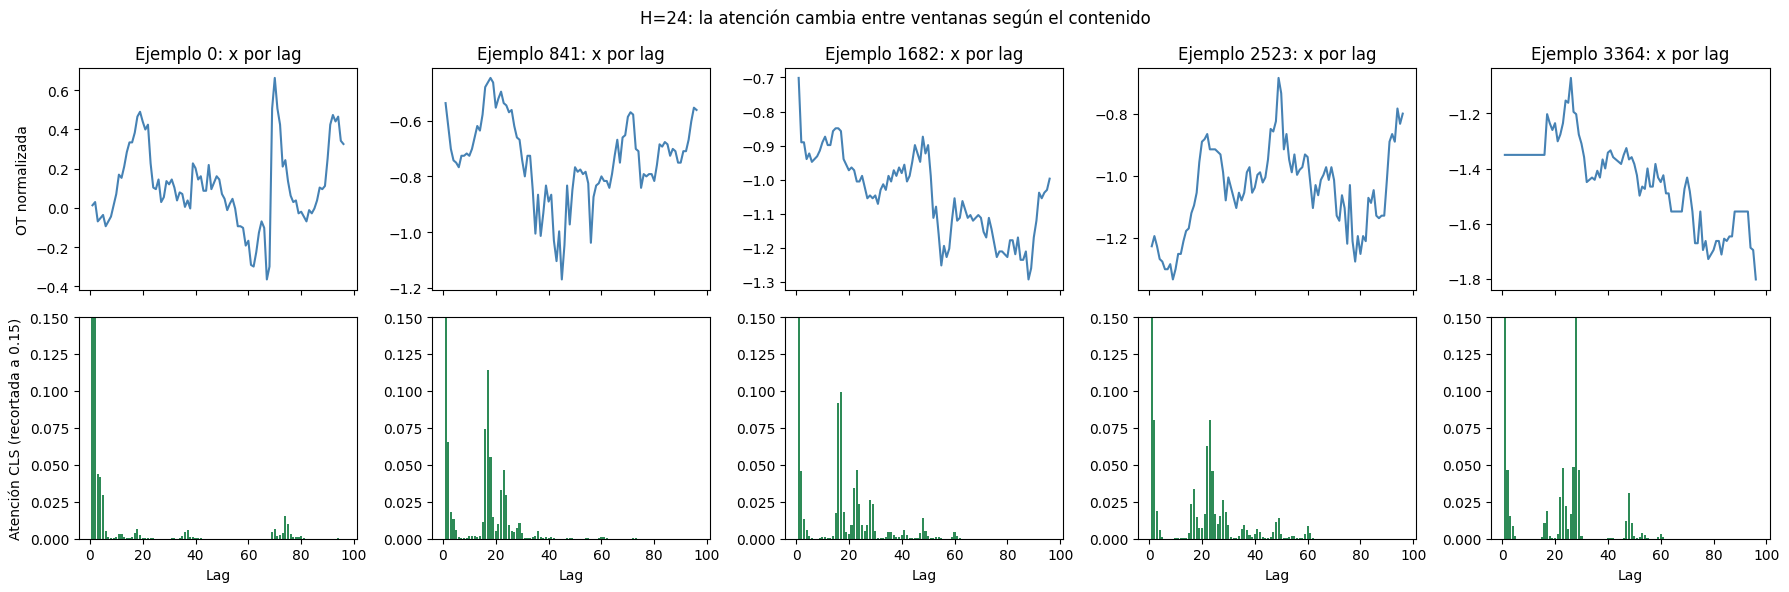

In [10]:
# Para ventanas de validación, correlación entre el peso CLS->s y el valor x_s dentro de cada ventana,
# excluyendo los lags 1-3 para que el efecto de "recencia" no domine.
torch.manual_seed(0)
for H in HORIZONS:
    X_vl, _ = windows[H]['val']
    idx = torch.randperm(X_vl.shape[0])[:500]
    Xs = X_vl[idx]
    w = cls_attention_by_lag(models['Transformer', H], Xs).mean(1)
    x_by_lag = Xs.flip(-1)
    mask = slice(3, L)
    corr_value = []
    corr_dist = []
    for i in range(Xs.shape[0]):
        corr_value.append(torch.corrcoef(torch.stack((w[i, mask], x_by_lag[i, mask])))[0, 1])
        dist = (x_by_lag[i, mask] - x_by_lag[i, 0]).abs()             # |x_s - x_t| respecto al último valor
        corr_dist.append(torch.corrcoef(torch.stack((w[i, mask], dist)))[0, 1])
    corr_value = torch.stack(corr_value)
    corr_dist = torch.stack(corr_dist)
    print(f'H={H}: corr(atención, x_s) media={corr_value.nanmean():+.3f} '
          f'(|corr|>0.3 en {(corr_value.abs() > 0.3).float().mean():.0%} de las ventanas); '
          f'corr(atención, |x_s - x_t|) media={corr_dist.nanmean():+.3f}')

# Heatmap
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=True)
X_vl, _ = windows[24]['val']
idx = attention_indices(X_vl)
for i, ex in enumerate(idx.tolist()):
    axes[0, i].plot(lag_axis, X_vl[ex].flip(0), color='steelblue')
    axes[0, i].set_title(f'Ejemplo {ex}: x por lag')
    axes[1, i].bar(lag_axis, cls_attn[24][i].mean(0), color='seagreen')
    axes[1, i].set_ylim(0, 0.15)
    axes[1, i].set_xlabel('Lag')
axes[0, 0].set_ylabel('OT normalizada')
axes[1, 0].set_ylabel('Atención CLS (recortada a 0.15)')
plt.suptitle('H=24: la atención cambia entre ventanas según el contenido')
plt.tight_layout()
plt.show()

### Respuesta 4.1b: dependencias que la atención puede capturar y la ACF no

La ACF resume cada lag $k$ con **un solo número** $\rho(k)$: una relación lineal promedio entre $x_t$ y $x_{t-k}$, igual para toda la serie. El score de atención
$e_{0s} = \mathbf{q}_0^\top \mathbf{k}_s/\sqrt{d_k}$ se calcula a partir de proyecciones de los **valores** de la ventana, y el softmax lo vuelve no lineal. Por eso, cuánto pesa el paso $s$ depende del contenido de cada ventana concreta. Esto le permite capturar:

- **Dependencias condicionales o de régimen:** el lag relevante puede cambiar según la situación (por ejemplo, un transformador calentándose frente a uno enfriándose, días de alta frente a baja carga). La ACF promedia todos los regímenes en un único coeficiente.
- **Interacciones entre lags:** combinaciones como la tendencia diaria $x_t - x_{t-24}$ o "el máximo del día anterior". Ninguna es una correlación entre un par $(x_t, x_{t-k})$.
- **Relaciones no lineales o no monótonas**, que pueden tener correlación lineal cercana a cero aunque la dependencia sea fuerte (por ejemplo, que importen los picos pero no los valores intermedios).

**Evidencia en los mapas de atención** (con cautela, porque la atención no equivale a importancia causal):

1. **El patrón cambia entre ventanas.** Si la dependencia fuera fija por lag, como supone la ACF, las 5 ventanas tendrían la misma distribución. En H=24 no es así:
   - Ejemplo 0: top-3 lags [1, 2, 3], entropía 1.60.
   - Ejemplo 841: [1, 17, 16], entropía 2.27.
   - Ejemplo 2523: [1, 23, 2], entropía 2.58.
   - Ejemplo 3364: [1, 28, 27], entropía 2.15.
   - El coeficiente de variación promedio del peso por lag entre ejemplos es 1.23 (1.08 en H=48). Es decir, la parte "diaria" de la atención se mueve dentro del rango 16–28 según el contenido de la ventana.
2. **La atención depende del valor, no solo de la distancia.** En 500 ventanas de validación, excluyendo los lags 1–3, la correlación entre el peso de atención y el valor $x_s$ es en promedio +0.22 (H=24) y +0.19 (H=48). Supera 0.3 en valor absoluto en el 41 % y el 52 % de las ventanas. El modelo tiende a mirar las horas de mayor temperatura (los picos del ciclo diario), dondequiera que caigan en la ventana. En cambio, la correlación con la distancia al último valor $|x_s - x_t|$ es casi nula (−0.02 y −0.06), así que no es una simple búsqueda de valores similares.
3. **Las cabezas se especializan** (ver 4.1a): una cabeza modela recencia y otra el ciclo diario. Esa división de funciones no existe en la ACF.

La evidencia es moderada. El efecto de contenido tiene correlaciones del orden de 0.2 y el modelo es de una sola capa. Aun así, muestra que la atención no es una función fija del lag, que es exactamente lo que la ACF supone.

# Task 4.2: Comparación LSTM vs Transformer

In [11]:
def regression_metrics(y, pred):
    return {
        'MAE': torch.abs(y - pred).mean().item(),
        'RMSE': torch.sqrt(torch.mean((y - pred).square())).item(),
    }

rows = []
naive_mae = {}
for H in HORIZONS:
    X_vl, y_vl = windows[H]['val']
    naive = regression_metrics(y_vl, X_vl[:, -1])        # naive: y_hat(t+H) = x_t
    naive_mae[H] = naive['MAE']
    for name in MODEL_FACTORIES:
        m = regression_metrics(y_vl, predict_batched(models[name, H], X_vl))
        rows.append({'Modelo': name, 'Horizonte': f'{H}h', **m, 'Ratio vs naive': m['MAE'] / naive['MAE']})
for H in HORIZONS:
    X_vl, y_vl = windows[H]['val']
    rows.append({'Modelo': 'Naive', 'Horizonte': f'{H}h',
                 **regression_metrics(y_vl, X_vl[:, -1]), 'Ratio vs naive': 1.0})

results = pd.DataFrame(rows).set_index(['Modelo', 'Horizonte'])
print('Métricas de validación (OT normalizada)')
display(results.round(4))

results_celsius = results[['MAE', 'RMSE']] * sigma.item()
print('Métricas de validación en °C (multiplicadas por sigma)')
display(results_celsius.round(3))

Métricas de validación (OT normalizada)


MAE    RMSE  Ratio vs naive
Modelo      Horizonte                                
LSTM        24h        0.2389  0.3058          1.1968
Transformer 24h        0.2326  0.2977          1.1651
LSTM        48h        0.3226  0.3978          1.2387
Transformer 48h        0.2620  0.3316          1.0063
Naive       24h        0.1996  0.2672          1.0000
            48h        0.2604  0.3359          1.0000

Métricas de validación en °C (multiplicadas por sigma)


MAE   RMSE
Modelo      Horizonte              
LSTM        24h        2.047  2.620
Transformer 24h        1.992  2.550
LSTM        48h        2.763  3.408
Transformer 48h        2.245  2.840
Naive       24h        1.710  2.289
            48h        2.231  2.878

## 1. Crecimiento del error con el horizonte

phi = ACF(1) = 0.9923, sigma_eps^2 = 0.0153
  h= 1: Var(e) iterativa AR(1) = 0.0153  (RMSE=0.1236)
  h= 6: Var(e) iterativa AR(1) = 0.0882  (RMSE=0.2969)
  h=12: Var(e) iterativa AR(1) = 0.1686  (RMSE=0.4106)
  h=24: Var(e) iterativa AR(1) = 0.3087  (RMSE=0.5556)
  h=48: Var(e) iterativa AR(1) = 0.5222  (RMSE=0.7226)

H=24: rho(H) train=0.9250, 1-rho^2 = 0.1445; corr(x_t, x_(t+H)) en val=0.8558; MAE naive=0.1996
H=48: rho(H) train=0.8763, 1-rho^2 = 0.2320; corr(x_t, x_(t+H)) en val=0.7709; MAE naive=0.2604


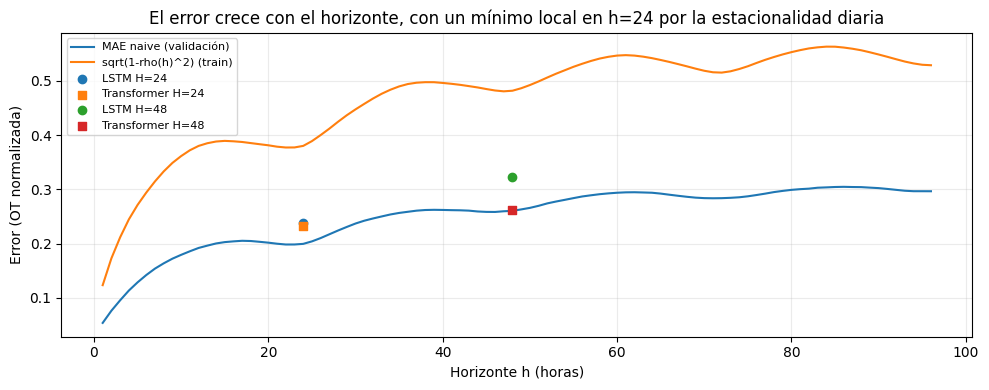

In [12]:
# Predicción iterativa
phi = acf_values[1].item()
sigma_eps2 = 1 - phi ** 2                  # varianza de la innovación para una serie de varianza 1
def iter_var(h):
    return sigma_eps2 * (1 - phi ** (2 * h)) / (1 - phi ** 2)

print(f'phi = ACF(1) = {phi:.4f}, sigma_eps^2 = {sigma_eps2:.4f}')
for h in (1, 6, 12, 24, 48):
    print(f'  h={h:2d}: Var(e) iterativa AR(1) = {iter_var(h):.4f}  (RMSE={iter_var(h) ** 0.5:.4f})')

# Predicción directa
print()
for H in HORIZONS:
    X_vl, y_vl = windows[H]['val']
    empirical_rho = torch.corrcoef(torch.stack((X_vl[:, -1], y_vl)))[0, 1].item()
    print(f'H={H}: rho(H) train={acf_values[H]:.4f}, 1-rho^2 = {1 - acf_values[H] ** 2:.4f}; '
          f'corr(x_t, x_(t+H)) en val={empirical_rho:.4f}; MAE naive={naive_mae[H]:.4f}')

hs = torch.arange(1, 97)
X_all, _ = make_windows(OT_val, L, 1)
naive_curve = []
for h in hs.tolist():
    Xh, yh = make_windows(OT_val, L, h)
    naive_curve.append(torch.abs(yh - Xh[:, -1]).mean().item())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hs, naive_curve, label='MAE naive (validación)')
ax.plot(hs, [(1 - acf_values[h].item() ** 2) ** 0.5 for h in hs.tolist()], label='sqrt(1-rho(h)^2) (train)')
for H in HORIZONS:
    for name, marker in (('LSTM', 'o'), ('Transformer', 's')):
        ax.scatter(H, results.loc[(name, f'{H}h'), 'MAE'], marker=marker, zorder=3,
                   label=f'{name} H={H}')
ax.set_xlabel('Horizonte h (horas)')
ax.set_ylabel('Error (OT normalizada)')
ax.set_title('El error crece con el horizonte, con un mínimo local en h=24 por la estacionalidad diaria')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Tabla comparativa (validación, OT normalizada)

| Modelo | Horizonte | MAE | RMSE | Ratio vs naive |
|---|---|---|---|---|
| LSTM | 24h | 0.2389 | 0.3058 | 1.197 |
| LSTM | 48h | 0.3226 | 0.3978 | 1.239 |
| Transformer | 24h | 0.2326 | 0.2977 | 1.165 |
| Transformer | 48h | 0.2620 | 0.3316 | 1.006 |
| Naive | 24h | 0.1996 | 0.2672 | 1.000 |
| Naive | 48h | 0.2604 | 0.3359 | 1.000 |

En °C, el MAE va de 1.99 °C (Transformer, 24h) a 2.76 °C (LSTM, 48h).

Con 20 épocas y una entrada univariada, ningún modelo supera claramente al naive $\hat{x}_{t+H} = x_t$. El Transformer con H=48 prácticamente lo iguala (ratio 1.006) y tiene un RMSE menor que el naive (0.332 frente a 0.336). Con $\rho(24)=0.925$ y $\rho(48)=0.876$, la persistencia es un baseline muy fuerte para esta serie.

### Respuesta 4.2a: ¿por qué crece el error con el horizonte?

**Caso iterativo (predicción paso a paso).** Supongamos que un modelo de un paso $\hat{x}_{t+1} = f(x_t, \dots)$ se aplica de forma recursiva, usando cada predicción como entrada de la siguiente. El error a $h$ pasos es

$$e_{t+h} = x_{t+h} - \hat{x}_{t+h|t} = \varepsilon_{t+h} + \frac{\partial f}{\partial x}\, e_{t+h-1} + \dots \;\;\Rightarrow\;\; e_{t+h} \approx \sum_{j=0}^{h-1} J^{\,j}\, \varepsilon_{t+h-j}$$

Si las innovaciones son independientes:

$$\operatorname{Var}(e_{t+h}) = \sigma_\varepsilon^2 \sum_{j=0}^{h-1} \|J^{\,j}\|^2 \;\overset{\text{AR(1)}}{=}\; \sigma_\varepsilon^2\,\frac{1-\phi^{2h}}{1-\phi^2}$$

Cada paso agrega un término positivo, así que la varianza del error crece de forma monótona con $h$. Si además el modelo tiene un sesgo $\delta$ por paso, el sesgo también se acumula: $\delta\,(1-\phi^h)/(1-\phi)$.

Con $\phi = \mathrm{ACF}(1) = 0.9923$ y $\sigma_\varepsilon^2 = 1-\phi^2 = 0.0153$:
- $h=1$: $\operatorname{Var}=0.015$
- $h=24$: $0.309$ (RMSE 0.556)
- $h=48$: $0.522$ (RMSE 0.723)

Duplicar el horizonte aumenta la varianza del error en un 69 %.

**Caso directo (nuestra implementación).** Aquí no hay retroalimentación de errores, pero el error sigue creciendo porque la ventana contiene **menos información** sobre un objetivo más lejano. El error mínimo alcanzable,

$$\mathbb{E}\big[(x_{t+H} - \mathbb{E}[x_{t+H}\mid x_{t-L+1:t}])^2\big],$$

crece con $H$. Para el mejor predictor lineal basado en $x_t$, ese mínimo es $\sigma^2(1-\rho(H)^2)$:
- $H=24$: $1-0.925^2 = 0.1445$
- $H=48$: $1-0.876^2 = 0.2320$, un **60 % mayor**

En validación, la correlación entre $x_t$ y $x_{t+H}$ cae de 0.856 a 0.771. Todos los modelos reflejan ese aumento:

| Modelo | MAE H=24 | MAE H=48 | Aumento |
|---|---|---|---|
| Naive | 0.1996 | 0.2604 | +30 % |
| LSTM | 0.2389 | 0.3226 | +35 % |
| Transformer | 0.2326 | 0.2620 | +13 % |

Además de la pérdida de información, otros factores empujan en la misma dirección:
- Entre $t$ y $t+H$ ocurren más perturbaciones no observadas (carga, clima), cuya varianza se suma.
- El cambio de distribución entre entrenamiento y validación pesa más a horizontes largos. $\rho(48)$ es 0.876 en entrenamiento pero solo 0.771 en validación.

La curva MAE naive frente a $h$ muestra que el crecimiento no es estrictamente monótono. Hay mínimos locales en $h \approx 24, 48$ por la estacionalidad diaria, pero la tendencia general es creciente.

## 2. Flujo del gradiente: LSTM vs Transformer

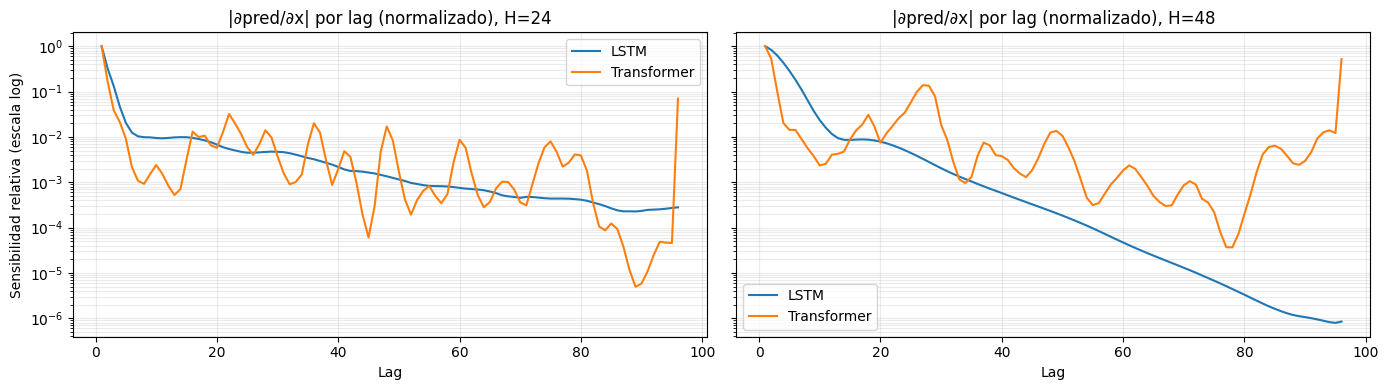

g(lag 24)/g(lag 1)  g(lag 48)/g(lag 1)  g(lag 96)/g(lag 1)  \
Modelo      H                                                                
LSTM        24              0.0047              0.0014              0.0003   
            48              0.0051              0.0002              0.0000   
Transformer 24              0.0115              0.0171              0.0698   
            48              0.0341              0.0125              0.5197   

                fracción lags 1-24  fracción lags 25-96  
Modelo      H                                            
LSTM        24              0.9438               0.0562  
            48              0.9909               0.0091  
Transformer 24              0.8346               0.1654  
            48              0.6017               0.3983

In [13]:
def input_gradient_by_lag(model, X):
    model.eval()
    X = X.clone().requires_grad_(True)
    model(X).sum().backward()
    return X.grad.abs().mean(0).flip(0)        # índice k-1 = lag k

torch.manual_seed(0)
grad_by_lag = {}
for H in HORIZONS:
    X_vl, _ = windows[H]['val']
    idx = torch.randperm(X_vl.shape[0])[:512]
    for name in MODEL_FACTORIES:
        grad_by_lag[name, H] = input_gradient_by_lag(models[name, H], X_vl[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, H in zip(axes, HORIZONS):
    for name in MODEL_FACTORIES:
        g = grad_by_lag[name, H]
        ax.semilogy(lag_axis, g / g.max(), label=name)
    ax.set_title(f'|∂pred/∂x| por lag (normalizado), H={H}')
    ax.set_xlabel('Lag')
    ax.grid(alpha=0.25, which='both')
    ax.legend()
axes[0].set_ylabel('Sensibilidad relativa (escala log)')
plt.tight_layout()
plt.show()

grad_rows = []
for name in MODEL_FACTORIES:
    for H in HORIZONS:
        g = grad_by_lag[name, H]
        share = g / g.sum()
        grad_rows.append({
            'Modelo': name, 'H': H,
            'g(lag 24)/g(lag 1)': (g[23] / g[0]).item(),
            'g(lag 48)/g(lag 1)': (g[47] / g[0]).item(),
            'g(lag 96)/g(lag 1)': (g[95] / g[0]).item(),
            'fracción lags 1-24': share[:24].sum().item(),
            'fracción lags 25-96': share[24:].sum().item(),
        })
display(pd.DataFrame(grad_rows).set_index(['Modelo', 'H']).round(4))

In [14]:
# Factor de olvido medio del LSTM
def lstm_forget_gates(model, X):
    with torch.no_grad():
        x = X.unsqueeze(-1)
        B, L, _ = x.shape
        h = x.new_zeros(B, model.d_h)
        c = x.new_zeros(B, model.d_h)
        forget = []
        for t in range(L):
            gates = x[:, t, :] @ model.Wx.T + h @ model.Wh.T + model.b
            i, f, g, o = gates.chunk(4, dim=-1)
            i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g)
            c = f * c + i * g
            h = o * torch.tanh(c)
            forget.append(f)
        return torch.stack(forget, dim=1)

for H in HORIZONS:
    X_vl, _ = windows[H]['val']
    f = lstm_forget_gates(models['LSTM', H], X_vl[:512])
    log_f = f.clamp_min(1e-8).log()
    cum = log_f.flip(1).cumsum(1).exp().mean(dim=(0, 2))
    print(f'H={H}: f medio={f.mean():.3f}; prod f (lag 24)={cum[23]:.2e}, '
          f'(lag 48)={cum[47]:.2e}, (lag 96)={cum[95]:.2e}')

H=24: f medio=0.707; prod f (lag 24)=1.10e-03, (lag 48)=1.69e-05, (lag 96)=2.17e-09
H=48: f medio=0.709; prod f (lag 24)=1.88e-03, (lag 48)=2.04e-05, (lag 96)=1.65e-09


### Respuesta 4.2b: diferencia en el flujo del gradiente

En esta ejecución, el Transformer supera claramente al LSTM en H=48: MAE 0.2620 frente a 0.3226 (−19 %), con ratio 1.006 frente a 1.239. En H=24 la diferencia es marginal, 0.2326 frente a 0.2389 (−2.6 %). Esa diferencia está dentro de la variabilidad entre ejecuciones. En las ejecuciones guardadas en `task_2_lstm.ipynb` y `task_3_transformer.ipynb`, el LSTM quedó ligeramente mejor en H=24 (0.2161 frente a 0.2196). Por lo tanto, el patrón observado es el de la pregunta, una ventaja clara del Transformer solo en el horizonte largo.

**Gradiente en el LSTM.** La señal que llega a una entrada $x_s$ debe recorrer toda la cadena recurrente:

$$\frac{\partial \mathcal{L}}{\partial x_s} = \frac{\partial \mathcal{L}}{\partial h_T}\left(\prod_{k=s+1}^{T} \frac{\partial h_k}{\partial h_{k-1}}\right)\frac{\partial h_s}{\partial x_s}, \qquad \frac{\partial c_T}{\partial c_s} \approx \prod_{k=s+1}^{T} \operatorname{diag}(f_k)$$

La ruta aditiva de la celda atenúa el gradiente por un factor $f_k$ en cada paso. En nuestros modelos entrenados, la compuerta de olvido promedio es $\bar f \approx 0.71$, y el producto $\prod f_k$ decae así:

| Distancia | $\prod f_k$ |
|---|---|
| 24 pasos | $\approx 10^{-3}$ |
| 48 pasos | $\approx 2\times10^{-5}$ |
| 96 pasos | $\approx 2\times10^{-9}$ |

La sensibilidad medida $|\partial\,\text{pred}/\partial x|$ lo confirma: el gradiente en el lag 24 es solo 0.5 % del gradiente en el lag 1, y en el lag 48 es 0.14 % (H=24) o 0.02 % (H=48). El **94 % (H=24) y el 99 % (H=48)** de la sensibilidad cae en los lags 1–24. En la práctica, el LSTM solo aprende del último día de la ventana.

**Gradiente en el Transformer.** La salida CLS se conecta con cada posición en **un solo paso**:

$$\text{out}_0 = \sum_{s} \alpha_{0s}\, \mathbf{v}_s W_O,\qquad \mathbf{v}_s = (x_s W_{in} + \mathrm{PE}_s)W_V$$

$$\frac{\partial\, \text{out}_0}{\partial x_s} = \alpha_{0s}\, W_{in} W_V W_O \;+\; \sum_{s'} \frac{\partial \alpha_{0s'}}{\partial x_s}\,\mathbf{v}_{s'} W_O, \qquad \frac{\partial \alpha_{0s'}}{\partial e_{0s}} = \alpha_{0s'}(\delta_{ss'} - \alpha_{0s})$$

Aquí no hay un producto de $T-s$ jacobianos: la magnitud depende del peso de atención $\alpha_{0s}$, no de la distancia temporal, y la longitud del camino es $O(1)$. Medido en los modelos:
- Los lags 25–96 reciben el 16.5 % (H=24) y el 39.8 % (H=48) de la sensibilidad, frente a 5.6 % y 0.9 % en el LSTM.
- El gradiente en el lag 24 es 1.2 % (H=24) y 3.4 % (H=48) del gradiente en el lag 1, entre 2 y 7 veces más que en el LSTM.

Un detalle de esta arquitectura: la posición 0 que usamos como CLS es la observación **más antigua** (lag 96). Esa entrada también llega a la salida directamente por la conexión residual $x + \text{att\_out}$, sin pasar por la atención. Por eso el lag 96 tiene sensibilidad alta en el Transformer (52 % del gradiente en el lag 1 con H=48).

**Por qué la ventaja aparece solo en H=48.**
- **En H=24**, la información más útil es reciente y ya está en la fase correcta del ciclo diario. El sesgo de recencia del LSTM es un sesgo inductivo adecuado. Su gradiente se concentra justo donde está la señal, así que la ruta directa del Transformer no aporta mucho. Ambos modelos quedan cerca del naive.
- **En H=48**, predecir bien requiere combinar el valor reciente con el patrón del día anterior. Para el LSTM, esos lags reciben menos del 1 % del gradiente, así que en 20 épocas no puede aprender a usarlos. El Transformer recibe gradiente útil en esos lags a través de $\alpha_{0s}$ y puede explotar la estructura diaria. Por eso su error crece solo 13 % de H=24 a H=48, frente a 35 % en el LSTM.

## 3. Conclusiones

- Ambos modelos aprenden sobre todo persistencia (el lag 1) más una corrección basada en el ciclo diario. Por eso quedan cerca del baseline naive, que es muy fuerte en esta serie ($\rho(24)=0.925$).
- La atención coincide con la ACF a escala gruesa, pero difiere en el detalle. Selecciona lags con información no redundante (el lag 1 y el grupo de ~1 día) en lugar de los más correlacionados, y cambia según el contenido de cada ventana.
- La ventaja del Transformer en H=48 es consistente con su ruta de gradiente de longitud $O(1)$ hacia lags lejanos, frente a la atenuación $\prod f_k$ del LSTM.
- Variabilidad entre ejecuciones: las métricas cambian entre ejecuciones y equipos aunque se usen las mismas semillas. Con esta cantidad de épocas, diferencias menores a ~0.01 de MAE no deben interpretarse como significativas.

## Uso de IA generativa

Prompt utilizado: "Te comparto el notebook realizado para mi laboratorio de deep learning. ¿Me ayudas a verificar que todo esté resuelto de forma correcta?"

Por qué funcionó: el prompt permitió utilizar la herramienta como apoyo para revisar el trabajo realizado y contrastarlo con las instrucciones del laboratorio. De esta forma, fue posible identificar posibles errores o aspectos que requerían revisión antes de entregar la solución.